In [208]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from matplotlib.ticker import MultipleLocator #  controla a escala do eixos
sns.set_style('whitegrid')


In [209]:
df_eda = pd.read_csv('dados_processados.csv')

In [210]:
odds_melted = pd.melt(
    df_eda[['PSCH', 'PSCD', 'PSCA']],
    value_vars=['PSCH', 'PSCD', 'PSCA'],
    var_name='Tipo de ODD',
    value_name='Valor'
)

#odds_melted

In [211]:
df_eda.columns

Index(['Date', 'Season', 'Home', 'Away', 'HG', 'AG', 'Res', 'PSCH', 'PSCD',
       'PSCA', 'Date_parsed', 'p_home', 'p_draw', 'p_away', 'dif_prob',
       'goal_diff', 'goal_total', 'bucket_favoritismo', 'home_last5_goals',
       'away_last5_goals', 'home_last5_concede', 'away_last5_concede',
       'home_ewma_5_goals', 'away_ewma_5_goals', 'Res_num',
       'home_last5_winrate', 'away_last5_winrate', 'home_points',
       'away_points', 'home_last5_ppg', 'away_last5_ppg', 'entropy'],
      dtype='str')

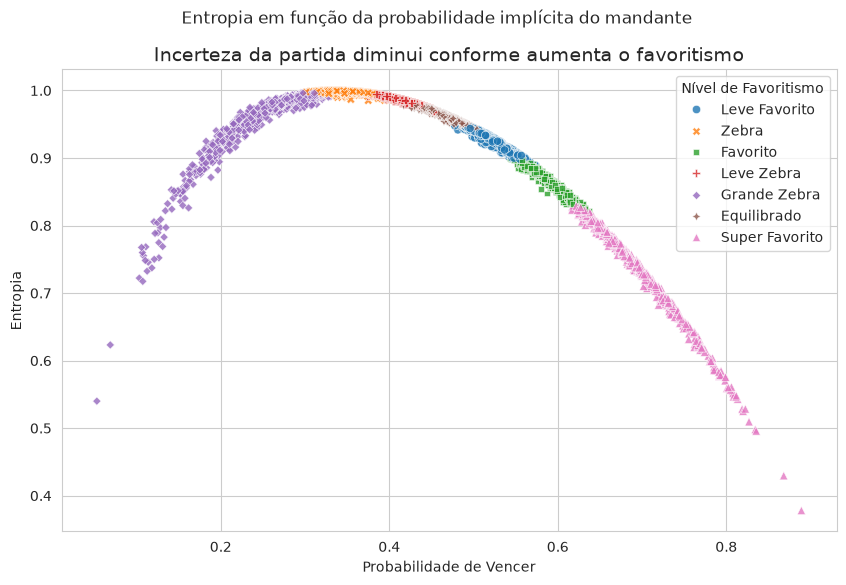

In [212]:
fig, ax = plt.subplots(figsize=(10, 6)) # controla o tamanho do plot
sns.scatterplot(data=df_eda,   x = 'p_home', y = 'entropy', hue = 'bucket_favoritismo', style='bucket_favoritismo', alpha = 0.8)

plt.suptitle('Entropia em função da probabilidade implícita do mandante', fontsize= 12)  # subtitulo do grafico 
plt.title('Incerteza da partida diminui conforme aumenta o favoritismo', fontsize = 14) # titulo do grafico 

plt.xlabel('Probabilidade de Vencer') # nome que vai eixo x 
plt.ylabel('Entropia') # nome que vai no eixo y 
plt.legend(title='Nível de Favoritismo') # altera o titulo da legenda 

plt.show()

Text(0, 0.5, 'Gols')

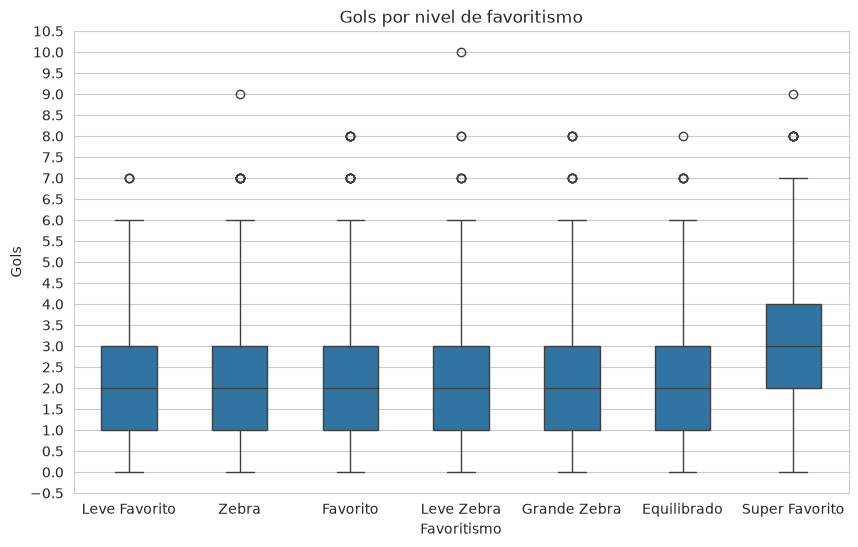

In [213]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data = df_eda, x = 'bucket_favoritismo', y = 'goal_total', width= 0.5)

ax.yaxis.set_major_locator(MultipleLocator(0.5))
#ax.set_yticks([0, 1.3, 1.5, 1.75, 2, 2.5, 3, 3.5, 4, 4.5])
plt.title('Gols por nivel de favoritismo')
plt.xlabel('Favoritismo')
plt.ylabel('Gols')

Text(0.5, 1.0, 'Comparação de odds')

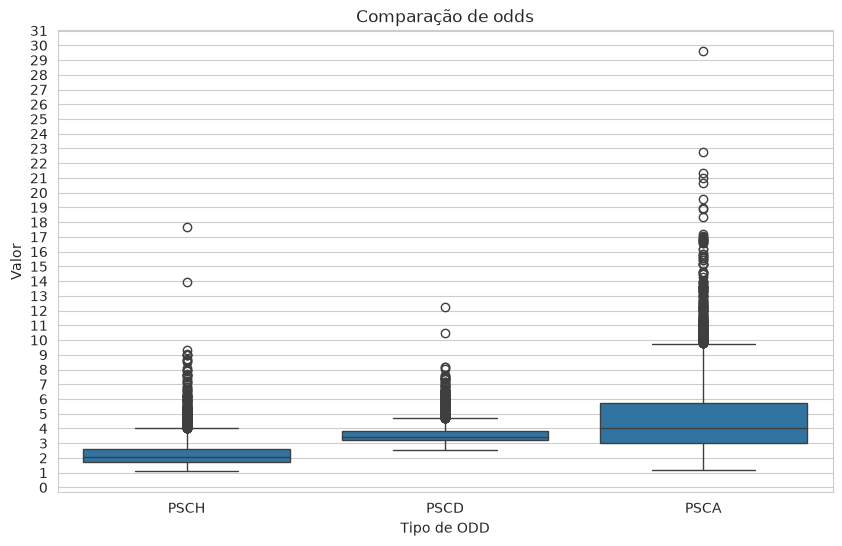

In [214]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data= odds_melted, x='Tipo de ODD', y = 'Valor')
ax.yaxis.set_major_locator(MultipleLocator(1))

ax.set_title("Comparação de odds")

<Axes: xlabel='Valor', ylabel='Density'>

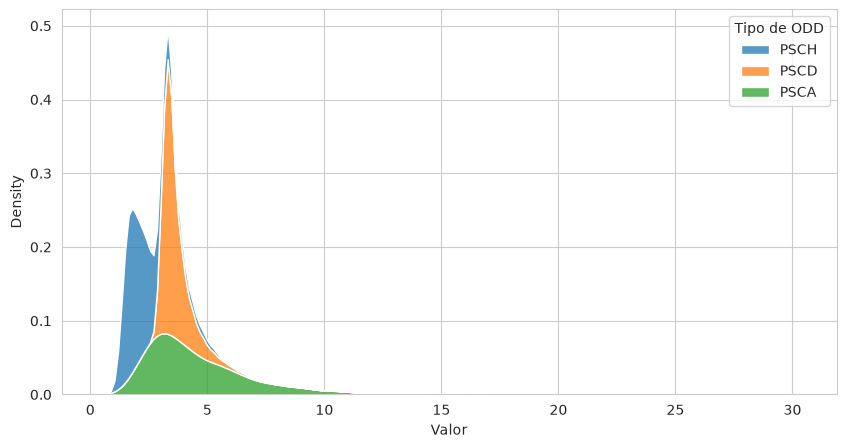

In [215]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(data= odds_melted, x = 'Valor', hue='Tipo de ODD', multiple="stack")

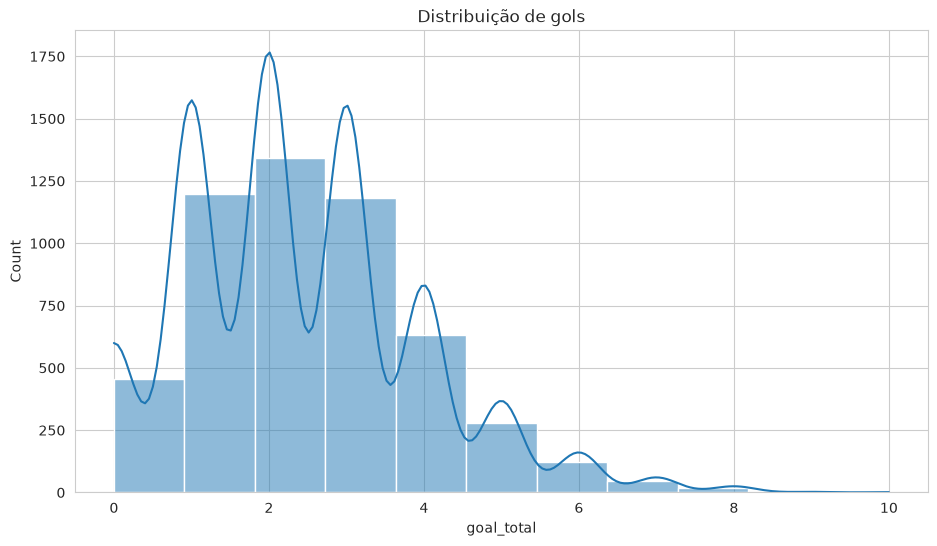

In [216]:
plt.figure(figsize=(11,6))
sns.histplot(data = df_eda, x='goal_total',bins=11, kde=True)
plt.title('Distribuição de gols')
plt.show()

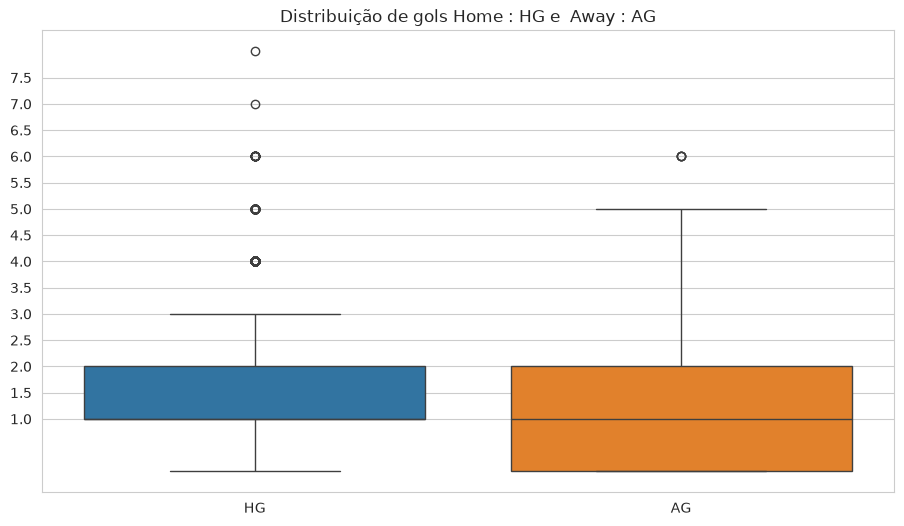

In [217]:
plt.figure(figsize=(11,6))
sns.boxplot(
    data = df_eda[['HG', 'AG']]
)

plt.title('Distribuição de gols Home : HG e  Away : AG')
plt.yticks(
    np.arange(1, 8, 0.5)
)

plt.show()

Text(0, 0.5, 'Quantidade')

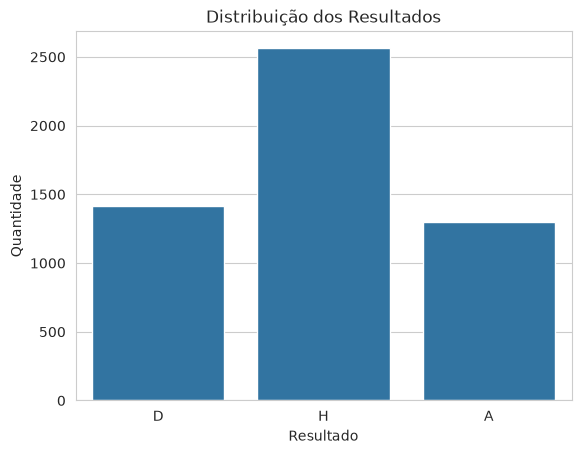

In [218]:
sns.countplot(data=df_eda, x ='Res')

plt.title('Distribuição dos Resultados')
plt.xlabel('Resultado')
plt.ylabel('Quantidade')

<Axes: xlabel='Res', ylabel='bucket_favoritismo'>

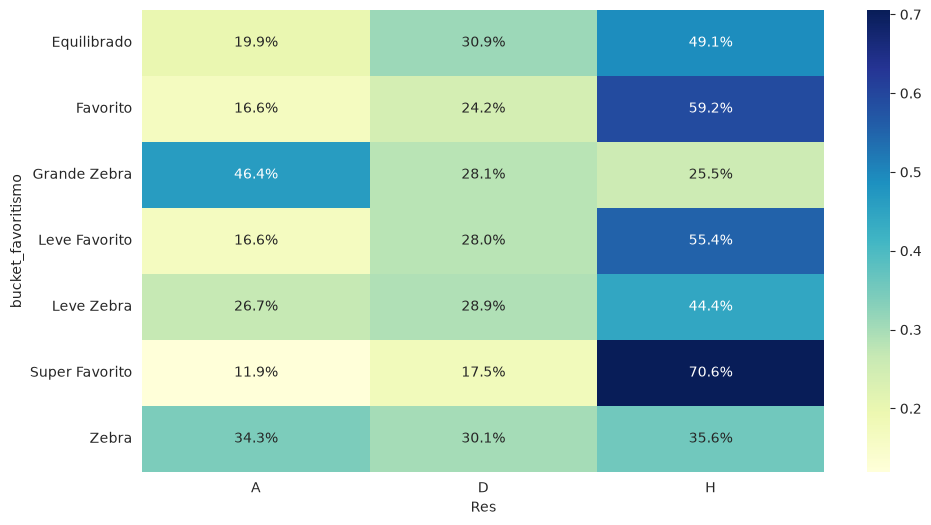

In [219]:
# Cria uma tabela de contingência (frequência cruzada) entre
# o nível de favoritismo (linhas) e o resultado da partida (colunas).
tabela = pd.crosstab(
    df_eda['bucket_favoritismo'],
    df_eda['Res'],
    normalize='index'
)



# normalize='index' faz com que cada linha some 100%,
# mostrando a proporção de H, D e A dentro de cada bucket.


plt.figure(figsize=(11,6))
sns.heatmap(
    tabela,
    annot=True, # Exibe os valores dentro de cada célula.
    fmt='.1%', # Formata os valores como porcentagem com uma casa decimal
    # (ex.: 72.3%).
    cmap='YlGnBu' # Define a paleta de cores utilizada no mapa de calor.
    # YlGnBu = Amarelo → Verde → Azul.
)

<Axes: xlabel='Res', ylabel='home_last5_winrate'>

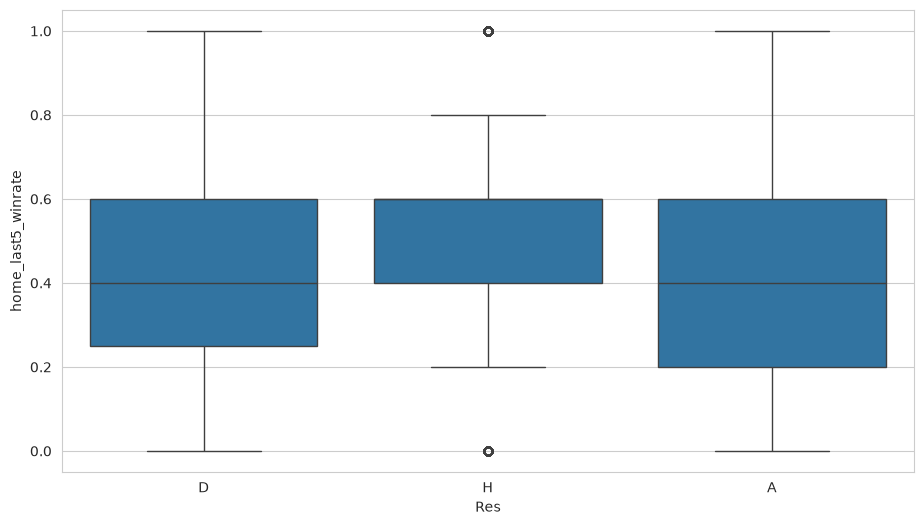

In [220]:
plt.figure(figsize=(11,6))
sns.boxplot(data= df_eda, x = 'Res', y = 'home_last5_winrate')

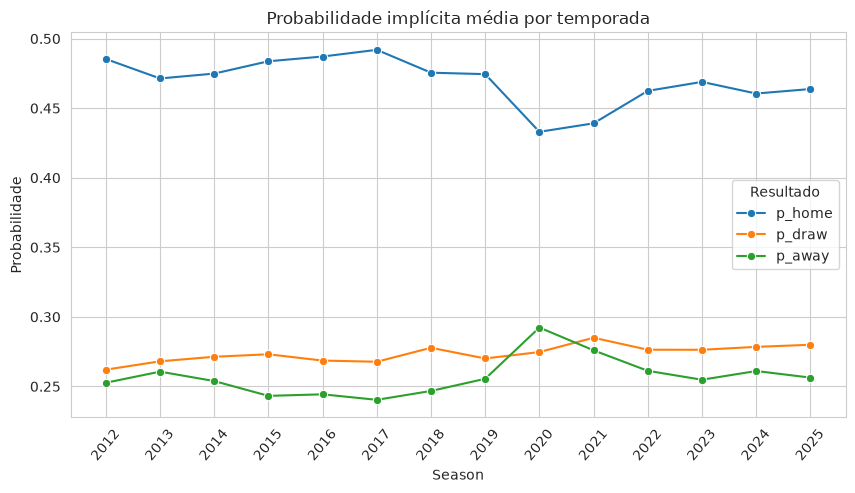

In [221]:
df_plot = (
    df_eda
    .groupby("Season")[["p_home","p_draw","p_away"]]
    .mean()
    .reset_index()
    .melt(
        id_vars="Season",
        var_name="Resultado",
        value_name="Probabilidade"
    )
)

plt.figure(figsize=(10,5))

sns.lineplot(
    data=df_plot,
    x="Season",
    y="Probabilidade",
    hue="Resultado",
    marker="o"
)

plt.title("Probabilidade implícita média por temporada")

plt.xticks(
    np.arange(2012, 2026, 1),
    rotation=50
)
plt.show()

In [222]:
df_eda.groupby('bucket_favoritismo')[['PSCH', 'PSCD', 'PSCA', 'HG', 'AG', 'goal_total','home_points',
       'away_points']].mean()

,PSCH,PSCD,PSCA,HG,AG,goal_total,home_points,away_points
bucket_favoritismo,,,,,,,,
Equilibrado,2.084422,3.337716,4.024807,1.405046,0.879150,2.284197,1.783533,0.907039
Favorito,1.649562,3.875471,6.087849,1.656042,0.820717,2.476760,2.018592,0.739708
Grande Zebra,4.046419,3.412414,2.157016,0.989390,1.352785,2.342175,1.045093,1.673740
Leve Favorito,1.846114,3.557347,4.876923,1.482759,0.830239,2.312997,1.942971,0.777188
Leve Zebra,2.364032,3.241273,3.386764,1.228117,0.980106,2.208223,1.622016,1.088859
Super Favorito,1.418634,4.833607,9.344483,2.034483,0.741379,2.775862,2.291777,0.533156
Zebra,2.755710,3.191833,2.859987,1.150066,1.143426,2.293493,1.369190,1.329349


In [223]:
def lucro_aposta(odd, resultado_real, resultado_esperado):
    """
    Retorna o lucro (em unidades) de uma aposta de 1 unidade.
    Se o resultado esperado for igual ao real, lucro = odd - 1.
    Caso contrário, perde-se 1 unidade.
    """
    if resultado_real == resultado_esperado:
      return odd - 1
    else:
        return -1

In [224]:
df_eda['lucro_home'] = df_eda.apply(lambda row: lucro_aposta(row['PSCH'], row['Res'], 'H'), axis=1)
df_eda['lucro_draw'] = df_eda.apply(lambda row: lucro_aposta(row['PSCD'], row['Res'], 'D'), axis=1)
df_eda['lucro_away'] = df_eda.apply(lambda row: lucro_aposta(row['PSCA'], row['Res'], 'A'), axis=1)

In [225]:
lucro_home = df_eda.groupby('Home')['lucro_home'].sum()
lucro_home = lucro_home.sort_values(ascending=False)

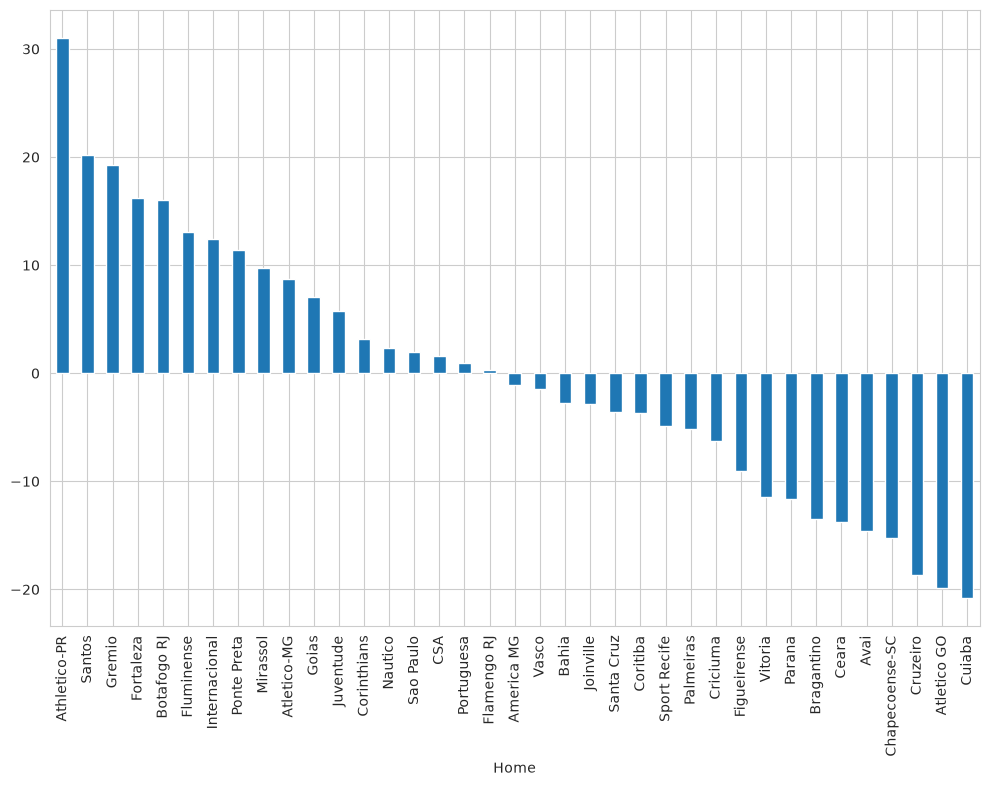

In [226]:
plt.figure(figsize=(12, 8))
lucro_home.plot(kind='bar')
plt.show()

In [227]:
lucro_away = df_eda.groupby('Away')['lucro_away'].sum()
lucro_away = lucro_away.sort_values(ascending=False)

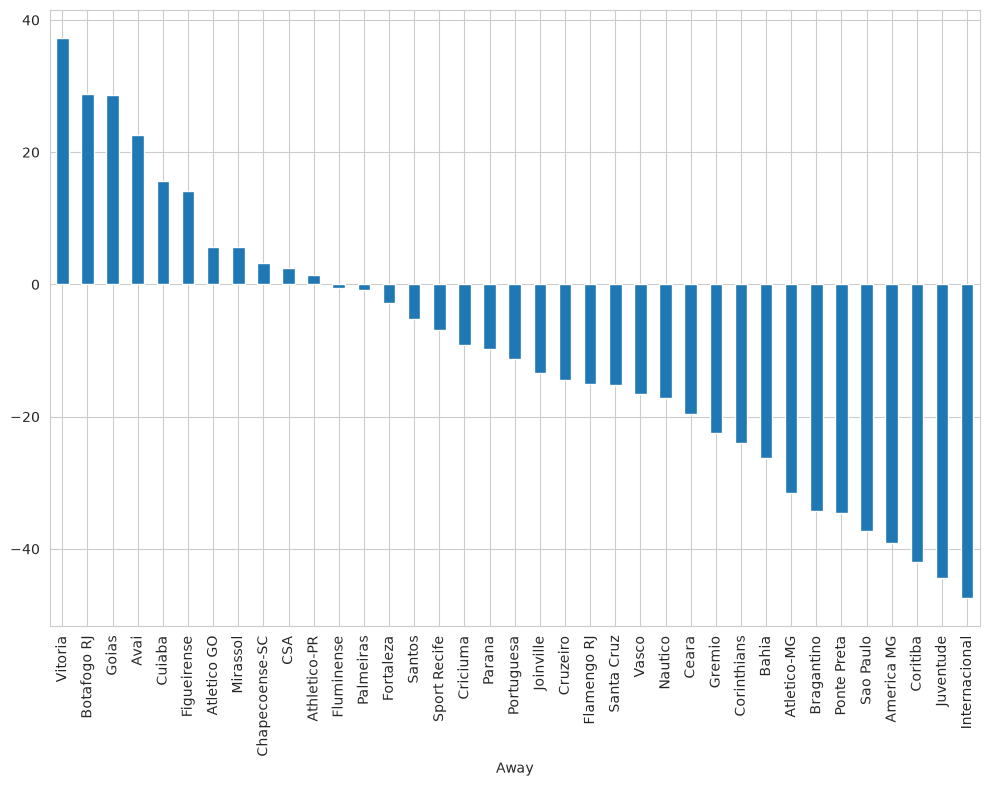

In [228]:
plt.figure(figsize=(12, 8))
lucro_away.plot(kind='bar')
plt.show()

In [229]:
lucro_total_por_time = lucro_home.add(lucro_away, fill_value=0)
lucro_total_por_time = lucro_total_por_time.sort_values(ascending=False)

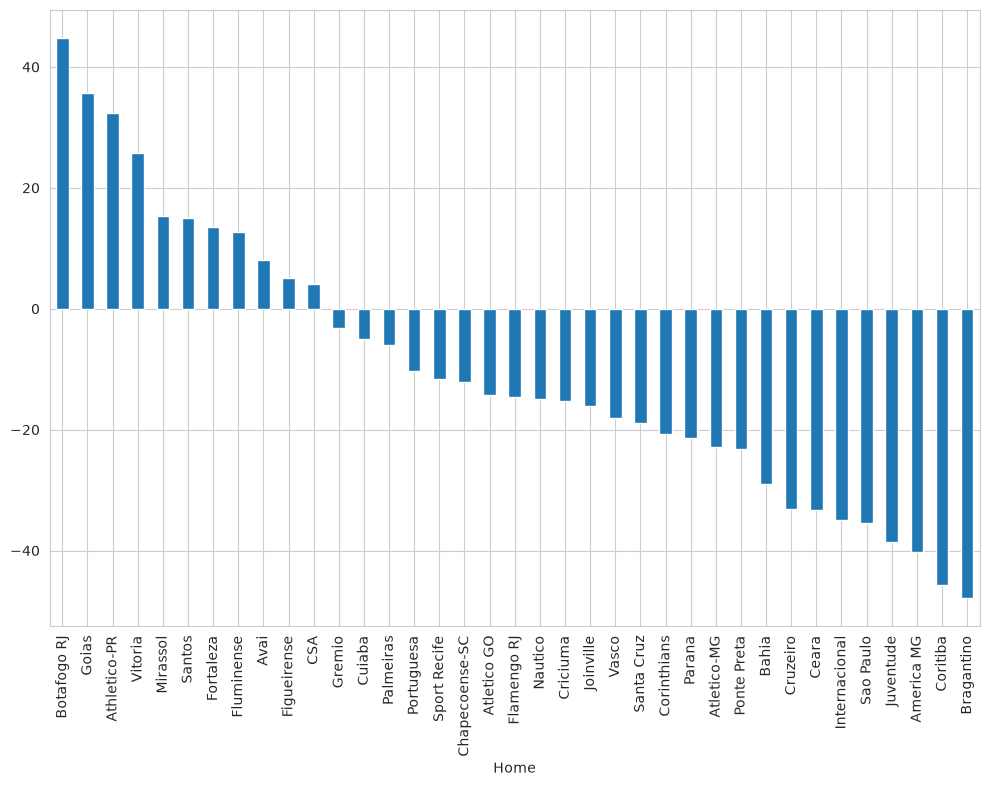

In [230]:
plt.figure(figsize=(12, 8))
lucro_total_por_time.plot(kind='bar')
plt.show()

In [231]:
cols = [ 
        
        'dif_prob',
        'home_last5_goals',
        'away_last5_goals',
        'home_last5_concede',
        'away_last5_concede',
        'home_ewma_5_goals',
        'away_ewma_5_goals',
        'home_last5_winrate',
        'away_last5_winrate',
        'home_last5_ppg',
        'away_last5_ppg',
        'entropy'
]

In [232]:
corr = df_eda[cols].corr()
# mascara : TRUE = esconder, False = mostrar
mask = np.triu(np.ones_like(corr, dtype=bool), k= 1)

Text(0.5, 1.0, 'Correlação de features preditivas')

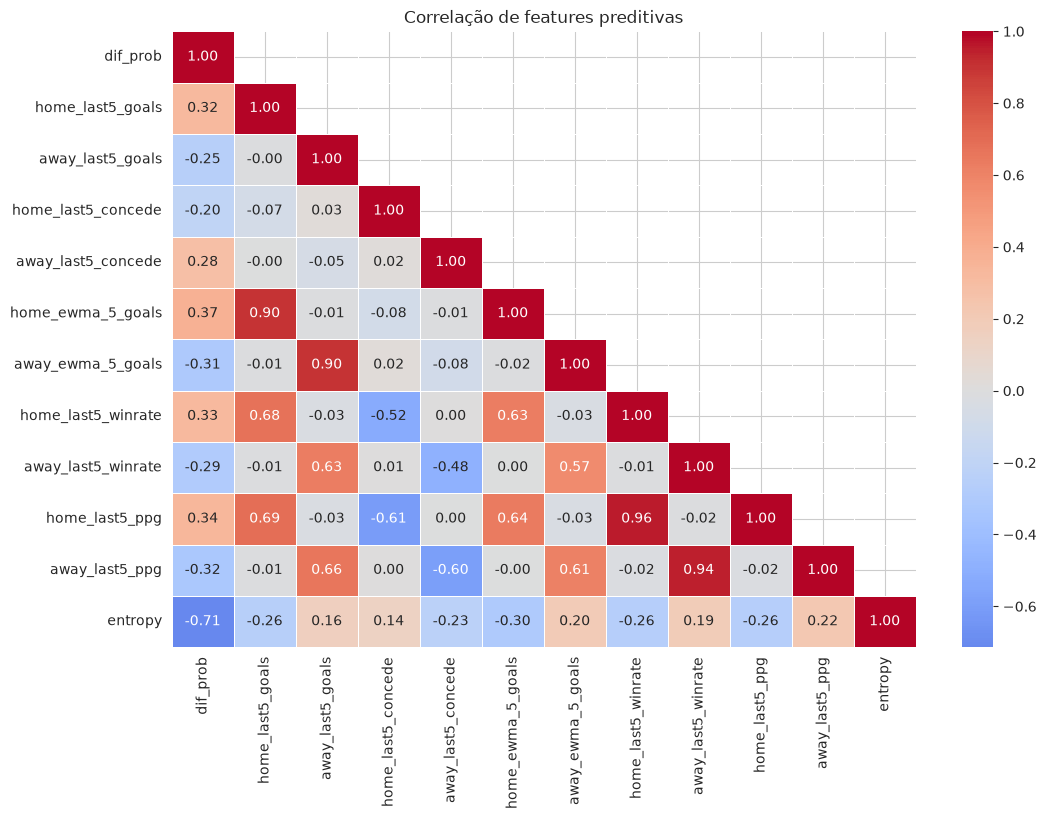

In [233]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr,mask=mask,  annot= True, fmt = '.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlação de features preditivas')

In [234]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools import add_constant
import warnings
warnings.filterwarnings('ignore') # ignorar alertas 

# VIF (variance inflation factor) 

In [235]:
feature = cols

In [236]:
df_clean = df_eda[feature].dropna()

In [237]:
# adicionar a constante ( interceptor) 
X = add_constant(df_clean)

In [238]:
# calcular o VIF uma a uma 
vif_list = []
for i, coluna in enumerate(X.columns):
    vif = variance_inflation_factor(X.values, i)
    vif_list.append({'Coluna': coluna, 'VIF': vif})

In [239]:
vid_df = pd.DataFrame(vif_list).sort_values('VIF', ascending= False).reset_index(
    drop=True
)

print(vid_df)

                Coluna         VIF
0                const  352.026764
1       home_last5_ppg   21.096815
2       away_last5_ppg   17.176242
3   home_last5_winrate   13.984564
4   away_last5_winrate   10.450837
5     home_last5_goals    7.514702
6     away_last5_goals    6.966302
7    home_ewma_5_goals    5.835288
8    away_ewma_5_goals    5.382694
9   away_last5_concede    2.786388
10  home_last5_concede    2.774292
11            dif_prob    2.483313
12             entropy    2.059665


# testar outras combinaçãoes de Features

In [240]:
df= pd.read_csv('dados_processados.csv')

In [241]:
df['home_goal_ratio'] = df['home_last5_goals'] / (df['home_last5_concede'] + 0.000001)
df['away_goal_ratio'] = df['away_last5_goals'] / (df['away_last5_concede'] + 0.000001)

In [242]:
df.columns

Index(['Date', 'Season', 'Home', 'Away', 'HG', 'AG', 'Res', 'PSCH', 'PSCD',
       'PSCA', 'Date_parsed', 'p_home', 'p_draw', 'p_away', 'dif_prob',
       'goal_diff', 'goal_total', 'bucket_favoritismo', 'home_last5_goals',
       'away_last5_goals', 'home_last5_concede', 'away_last5_concede',
       'home_ewma_5_goals', 'away_ewma_5_goals', 'Res_num',
       'home_last5_winrate', 'away_last5_winrate', 'home_points',
       'away_points', 'home_last5_ppg', 'away_last5_ppg', 'entropy',
       'home_goal_ratio', 'away_goal_ratio'],
      dtype='str')

In [243]:
cols_finais = [
    'dif_prob', # se mercado esta confiante em vitoria casa
    'entropy', # se há incerteza
    'home_goal_ratio', # eficiencia ofensiva/ defensiva casa
    'away_goal_ratio', # eficiencia ofensiva/ defensiva forA
    'home_last5_winrate', # que % dos ultimos 5 jogos o mantante ganhou
    'away_last5_winrate', # que % dos ultimos 5 jogos o visitante ganhou
    'home_last5_ppg',   # pontos por jogo recente
]

In [244]:
df_clean = df[cols_finais].dropna()
X = add_constant(df_clean)

In [245]:
vif_vals = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

In [246]:
vif_df = pd.DataFrame({
    'Feature': X.columns,
    'VIF' : vif_vals
}).sort_values('VIF', ascending=False).reset_index(drop=True)

In [247]:
print(vif_df)
print(f"/nVIf maximo (ignorando interceptor: {max(vif_vals[1:]):.2f})")


              Feature         VIF
0               const  259.734554
1      home_last5_ppg   12.945703
2  home_last5_winrate   12.782509
3            dif_prob    2.269891
4             entropy    2.046978
5  away_last5_winrate    1.110887
6     home_goal_ratio    1.027035
7     away_goal_ratio    1.012358
/nVIf maximo (ignorando interceptor: 12.95)


In [248]:
df['diff_winrate']     = df['home_last5_winrate'] - df['away_last5_winrate']

form_prob = df["diff_winrate"] * 0.5 + 0.5

# Quem está mais otimista em relação ao mandante forma ou mercado
df["market_form_direction"] = (
    df["p_home"] - form_prob
)

# Quanto mercado e forma discordam
df["market_form_divergence"] = np.abs(
    df["p_home"] - form_prob
)

<Axes: xlabel='market_form_divergence', ylabel='Res'>

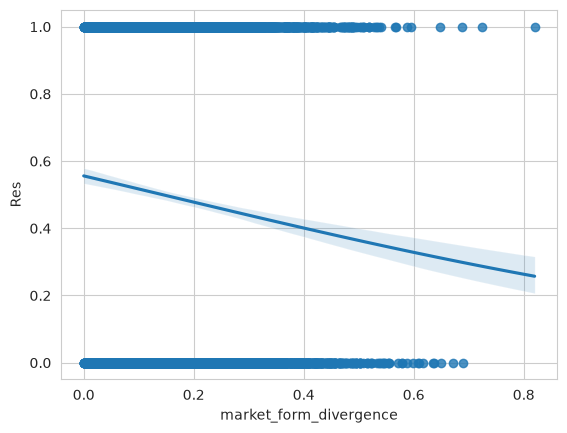

In [249]:
sns.regplot(
    data=df,
    x="market_form_divergence",
    y=(df["Res"]=="H").astype(int),
    logistic=True
)

In [250]:
df["bucket_direction"] = pd.qcut(
    df["market_form_direction"],
    q=5,
    labels=[
        "Mercado << Forma",
        "Mercado < Forma",
        "Equilibrado",
        "Mercado > Forma",
        "Mercado >> Forma"
    ]
)

pd.crosstab(
    df["bucket_direction"],
    df["Res"],
    normalize="index"
)

Res,A,D,H
bucket_direction,,,
Mercado << Forma,0.325359,0.275598,0.399043
Mercado < Forma,0.265326,0.260536,0.474138
Equilibrado,0.238506,0.282567,0.478927
Mercado > Forma,0.226054,0.250958,0.522989
Mercado >> Forma,0.180861,0.264115,0.555024


In [251]:
n = 8
df['faixa_home']  = pd.qcut(df['PSCH'], q = n)
df['faixa_draw']  = pd.qcut(df['PSCD'], q = n)
df['faixa_away']  = pd.qcut(df['PSCA'], q = n)

In [252]:
df["lucro_home"] = np.where(
    df["Res"]=="H",
    df["PSCH"]-1,
    -1
)

In [253]:
df["lucro_draw"] = np.where(
    df["Res"]=="D",
    df["PSCD"]-1,
    -1
)

In [254]:
df["lucro_away"] = np.where(
    df["Res"]=="A",
    df["PSCA"]-1,
    -1
)

In [255]:
roi_home = (
    df.groupby("faixa_home")
      .agg(
          jogos=("lucro_home","size"),
          odd_media=("PSCH","mean"),
          acerto=("Res",lambda x:(x=="H").mean()),
          lucro=("lucro_home","sum"),
          roi=("lucro_home","mean")
      )
)

In [256]:
roi_draw = (
    df.groupby("faixa_draw")
      .agg(
          jogos=("lucro_draw","size"),
          odd_media=("PSCD","mean"),
          acerto=("Res",lambda x:(x=="D").mean()),
          lucro=("lucro_draw","sum"),
          roi=("lucro_draw","mean")
      )
)

In [257]:
roi_away = (
    df.groupby("faixa_away")
      .agg(
          jogos=("lucro_away","size"),
          odd_media=("PSCA","mean"),
          acerto=("Res",lambda x:(x=="A").mean()),
          lucro=("lucro_away","sum"),
          roi=("lucro_away","mean")
      )
)

In [258]:
roi_draw

,jogos,odd_media,acerto,lucro,roi
faixa_draw,,,,,
"(2.539, 3.11]",673,3.015453,0.343239,22.37,0.033239
"(3.11, 3.24]",680,3.182338,0.272059,-91.44,-0.134471
"(3.24, 3.34]",686,3.295233,0.306122,6.50,0.009475
"(3.34, 3.44]",606,3.392244,0.257426,-76.63,-0.126452
"(3.44, 3.592]",652,3.511902,0.274540,-23.97,-0.036764
"(3.592, 3.83]",660,3.701500,0.290909,48.89,0.074076
"(3.83, 4.27]",662,4.020091,0.223565,-69.55,-0.105060
"(4.27, 12.25]",656,4.992332,0.173780,-99.47,-0.151631


In [259]:
roi_away

,jogos,odd_media,acerto,lucro,roi
faixa_away,,,,,
"(1.149, 2.48]",664,2.104096,0.477410,-10.64,-0.016024
"(2.48, 2.99]",669,2.761106,0.346786,-28.13,-0.042048
"(2.99, 3.45]",650,3.220938,0.286154,-54.54,-0.083908
"(3.45, 4.03]",663,3.729367,0.245852,-55.78,-0.084133
"(4.03, 4.72]",653,4.355237,0.163859,-187.56,-0.287228
"(4.72, 5.7]",660,5.208167,0.168182,-83.50,-0.126515
"(5.7, 7.28]",658,6.385198,0.167173,39.27,0.059681
"(7.28, 29.58]",658,9.693085,0.110942,5.25,0.007979


In [260]:
roi_home

,jogos,odd_media,acerto,lucro,roi
faixa_home,,,,,
"(1.0790000000000002, 1.53]",685,1.405168,0.705109,-9.63,-0.014058
"(1.53, 1.7]",681,1.623275,0.609398,-9.74,-0.014302
"(1.7, 1.88]",663,1.791297,0.565611,8.46,0.012760
"(1.88, 2.08]",633,1.988436,0.510269,9.24,0.014597
"(2.08, 2.312]",635,2.201654,0.469291,19.93,0.031386
"(2.312, 2.62]",663,2.465339,0.423831,27.47,0.041433
"(2.62, 3.168]",655,2.860321,0.348092,-1.61,-0.002458
"(3.168, 17.68]",660,4.184030,0.239394,-43.26,-0.065545


# filtra somente um time

In [261]:
df['Home'].unique()

<StringArray>
[     'Palmeiras',   'Sport Recife',    'Figueirense',    'Botafogo RJ',
    'Corinthians',  'Internacional',    'Ponte Preta',          'Bahia',
       'Cruzeiro',          'Vasco',    'Atletico GO',    'Flamengo RJ',
     'Portuguesa',         'Gremio',     'Fluminense',         'Santos',
      'Sao Paulo',    'Atletico-MG',        'Nautico',       'Coritiba',
        'Vitoria',       'Criciuma',   'Athletico-PR',          'Goias',
 'Chapecoense-SC',           'Avai',      'Joinville',     'Santa Cruz',
     'America MG',          'Ceara',         'Parana',            'CSA',
      'Fortaleza',     'Bragantino',         'Cuiaba',      'Juventude',
       'Mirassol']
Length: 37, dtype: str

In [272]:
time = "Vasco"

df_time = df[

    (df["Home"] == time) |
    (df["Away"] == time)
].copy()

In [273]:
df_time["odd_time"] = np.where(
    df_time["Home"] == time,
    df_time["PSCH"],
    df_time["PSCA"]
)

In [274]:
df_time["venceu"] = np.where(
    ((df_time["Home"] == time) & (df_time["Res"] == "H")) |
    ((df_time["Away"] == time) & (df_time["Res"] == "A")),
    1,
    0
)

In [275]:
df_time["lucro"] = np.where(
    df_time["venceu"] == 1,
    df_time["odd_time"] - 1,
    -1
)

In [276]:
df_time["faixa"] = pd.qcut(
    df_time["odd_time"],
    q=5
)

In [277]:
# df_time = df_time[df_time['Season'] >= 2022]

In [278]:
resultado = (
    df_time
    .groupby(['Season'])
    .agg(
        jogos=("lucro","size"),
        odd_media=("odd_time","mean"),
        vitorias=("venceu","sum"),
        taxa_vitoria=("venceu","mean"),
        lucro=("lucro","sum"),
        roi=("lucro","mean")
    )
)

print(f"Time: {time} \n")
print(resultado)

Time: Vasco 

        jogos  odd_media  vitorias  taxa_vitoria  lucro       roi
Season                                                           
2012       38   2.805263        16      0.421053   1.37  0.036053
2013       38   3.601316        11      0.289474  -4.18 -0.110000
2015       38   4.542632        10      0.263158  -0.01 -0.000263
2017       38   3.911053        15      0.394737   9.06  0.238421
2018       38   4.228158        10      0.263158 -13.54 -0.356316
2019       38   3.891579        12      0.315789  -1.91 -0.050263
2020       38   4.116842        10      0.263158  -8.84 -0.232632
2023       38   3.516053        12      0.315789  -6.22 -0.163684
2024       38   3.823947        14      0.368421   1.76  0.046316
2025       34   4.146471        13      0.382353   4.48  0.131765


In [279]:
df_time["prob_mercado"] = 1 / df_time["odd_time"]

In [280]:
resultado = (
    df_time.groupby("Season")
    .agg(
        jogos=("venceu", "size"),
        taxa_vitoria=("venceu", "mean"),
        prob_mercado=("prob_mercado", "mean"),
        roi=("lucro", "mean")
    )
)

resultado["edge"] = (
    resultado["taxa_vitoria"] -
    resultado["prob_mercado"]
)

print(f"Time: {time} \n")
print(resultado)

Time: Vasco 

        jogos  taxa_vitoria  prob_mercado       roi      edge
Season                                                       
2012       38      0.421053      0.406039  0.036053  0.015014
2013       38      0.289474      0.340661 -0.110000 -0.051187
2015       38      0.263158      0.299320 -0.000263 -0.036162
2017       38      0.394737      0.321931  0.238421  0.072806
2018       38      0.263158      0.308446 -0.356316 -0.045288
2019       38      0.315789      0.333556 -0.050263 -0.017767
2020       38      0.263158      0.292224 -0.232632 -0.029066
2023       38      0.315789      0.337312 -0.163684 -0.021523
2024       38      0.368421      0.315085  0.046316  0.053336
2025       34      0.382353      0.307008  0.131765  0.075345
